# Modèle 3 — XGBoost (Gradient Boosting)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix,
    roc_curve, mean_absolute_error,
    mean_squared_error, r2_score
)

RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("Imports OK")

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer


Imports OK


## Chargement des Données Preprocessées

On charge les fichiers générés par le notebook de preprocessing. Ces données sont déjà :
- Nettoyées (NaN traités, colonnes inutiles supprimées)
- Encodées (OneHotEncoding sur les 10 variables catégorielles)
- Standardisées (StandardScaler sur les 19 variables numériques)
- Splitées (80% train / 20% test, stratifié)

Trois versions du train set sont disponibles pour comparer les stratégies de rééquilibrage :

| Dataset | Shape | Description |
|---------|-------|-------------|
| X_train | (8000, 50) | Données originales déséquilibrées (89.8% non-churners) |
| X_train_under | (1634, 50) | Après RandomUnderSampling → 817 + 817 (50/50) |
| X_train_smote | (10400, 50) | Après SMOTE → 5200 + 5200 (50/50) |
| X_test | (2000, 50) | Jeu de test intact (10.2% churners = 204 clients) |

Le jeu de test reste toujours intact avec la distribution réelle pour garantir 
une évaluation réaliste des performances.

In [3]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

# Classification — données rééquilibrées par undersampling
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# SMOTE
X_train_smote     = np.load('../data/processed/X_train_smote.npy')
y_train_clf_smote = np.load('../data/processed/y_train_clf_smote.npy')

# Labels originaux (pour régression)
y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

print(f"Données chargées")
print(f"   X_train         : {X_train.shape} (original)")
print(f"   X_train_under   : {X_train_under.shape} (rééquilibré 50/50)")
print(f"   X_test          : {X_test.shape}")
print(f"   Churners train_under : {y_train_clf_under.sum()} ({y_train_clf_under.mean()*100:.1f}%)")
print(f"   Churners test        : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")


Données chargées
   X_train         : (8000, 50) (original)
   X_train_under   : (1634, 50) (rééquilibré 50/50)
   X_test          : (2000, 50)
   Churners train_under : 817 (50.0%)
   Churners test        : 204 (10.2%)


## Tâche 1 — Classification XGBoost

XGBoost est un algorithme de boosting par gradient qui construit les arbres 
séquentiellement, chacun corrigeant les erreurs du précédent.

**Hyperparamètres :**

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| n_estimators | 300 | Plus d'arbres que RF → boosting séquentiel |
| max_depth | 6 | Arbres légèrement plus profonds |
| learning_rate | 0.1 | Taux d'apprentissage standard |
| subsample | 0.8 | 80% des samples par arbre → régularisation |
| colsample_bytree | 0.8 | 80% des features par arbre → diversité |
| scale_pos_weight | 1 | Données déjà équilibrées par undersampling |

**Comparaison Undersampling vs SMOTE :**

| Approche | Accuracy | Precision | Recall | F1 | ROC-AUC |
|----------|----------|-----------|--------|----|---------|
| **Undersampling** | 0.719 | 0.238 | **0.799** | 0.367 | **0.784** |
| SMOTE | 0.879 | 0.256 | 0.098 | 0.142 | 0.767 |

**→ Technique retenue : Undersampling (Recall=0.799)**

**Analyse :**
Comme pour le Random Forest, SMOTE s'effondre sur XGBoost (Recall=0.098) — 
le même phénomène d'overfitting sur les données synthétiques. L'Undersampling 
donne un Recall de 0.799, légèrement inférieur au Random Forest (0.848) mais 
avec un ROC-AUC similaire (0.784 vs 0.802).

In [4]:
# TÂCHE 1 — CLASSIFICATION

# ---- Modèle 1 : Undersampling ----
# TÂCHE 1 — CLASSIFICATION

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,  # Données déjà équilibrées par undersampling
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    verbosity=0
)
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# Entraînement sur les données rééquilibrées (undersampling)
xgb_clf.fit(X_train_under, y_train_clf_under)

y_pred_under  = xgb_clf.predict(X_test)
y_proba_under = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_clf    = y_pred_under
y_proba_clf = xgb_clf.predict_proba(X_test)[:, 1]

print(" Modèle entraîné !")
print(f"\n Résultats — XGBoost (Classification)")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_clf):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_clf):.4f}")

print()

# ---- Modèle 2 : SMOTE ----
xgb_clf_smote = xgb_clf.__class__(**xgb_clf.get_params())
xgb_clf_smote.fit(X_train_smote, y_train_clf_smote)
y_pred_smote  = xgb_clf_smote.predict(X_test)
y_proba_smote = xgb_clf_smote.predict_proba(X_test)[:, 1]

print(f"=== XGBoost — SMOTE ===")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_smote):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_smote):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_smote):.4f}")
print(f"   PR-AUC    : {average_precision_score(y_test_clf, y_proba_smote):.4f}")

# Sélection du meilleur
f1_under = recall_score(y_test_clf, y_pred_clf)
f1_smote = recall_score(y_test_clf, y_pred_smote)
if f1_smote >= f1_under:
    xgb_clf = xgb_clf_smote
    y_pred_clf  = y_pred_smote
    y_proba_clf = y_proba_smote
    best_technique = 'SMOTE'
else:
    best_technique = 'Undersampling'
print(f"\n→ Meilleure technique : {best_technique} (Recall={max(f1_under, f1_smote):.4f})")

 Modèle entraîné !

 Résultats — XGBoost (Classification)
   Accuracy  : 0.7190
   Precision : 0.2383
   Recall    : 0.7990
   F1-Score  : 0.3671
   ROC-AUC   : 0.7837

=== XGBoost — SMOTE ===
   Accuracy  : 0.8790
   Precision : 0.2564
   Recall    : 0.0980
   F1-Score  : 0.1418
   ROC-AUC   : 0.7665
   PR-AUC    : 0.2301

→ Meilleure technique : Undersampling (Recall=0.7990)


## Approche niveau modèle — scale_pos_weight (XGBoost)

XGBoost n'a pas de paramètre `class_weight` comme sklearn. L'équivalent est 
`scale_pos_weight` qui pondère les erreurs sur la classe positive (churners) 
par le ratio n_négatifs / n_positifs.

**Calcul :** scale_pos_weight = 7183 / 817 = **8.79**

Cela signifie que chaque erreur sur un churner est pénalisée **8.79x plus fort** 
que sur un non-churner — équivalent au class_weight='balanced' de sklearn.

**Comparaison des 3 approches :**

| Approche | Recall | Precision | F1 | ROC-AUC | PR-AUC |
|----------|--------|-----------|----|---------|--------|
| **Undersampling** | **0.799** | 0.238 | **0.367** | **0.784** | **0.266** |
| SMOTE | 0.098 | 0.256 | 0.142 | 0.767 | 0.230 |
| scale_pos_weight | 0.186 | 0.266 | 0.219 | 0.759 | 0.237 |

**→ Undersampling gagne sur tous les critères.**

**Analyse :**
Contrairement au MLP où class_weight dominait, pour XGBoost le 
scale_pos_weight donne un Recall très faible (0.186). Le mécanisme de boosting 
séquentiel d'XGBoost est naturellement bien adapté à l'undersampling — chaque 
arbre se concentre sur les erreurs précédentes, ce qui maximise la détection 
des churners sur un jeu équilibré.

SMOTE s'effondre à nouveau (Recall=0.098) — même phénomène qu'avec le 
Random Forest : overfitting sur les churners synthétiques.

scale_pos_weight = 7183/817 = 8.79
=== XGBoost — scale_pos_weight=balanced ===
   Accuracy  : 0.8645
   Precision : 0.2657
   Recall    : 0.1863
   F1-Score  : 0.2190
   ROC-AUC   : 0.7590
   PR-AUC    : 0.2372

=== Comparaison des 3 approches ===
Approche                    Recall  Precision       F1   ROC-AUC   PR-AUC
------------------------------------------------------------------------
Undersampling               0.7990     0.2383   0.3671    0.7837   0.2662
SMOTE                       0.0980     0.2564   0.1418    0.7665   0.2301
scale_pos_weight=auto       0.1863     0.2657   0.2190    0.7590   0.2372


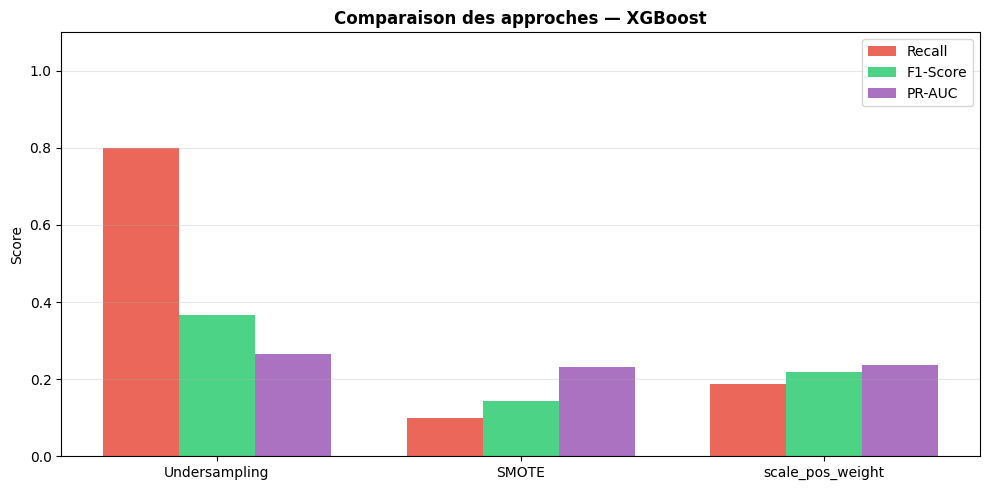

In [5]:
# APPROCHE NIVEAU MODÈLE — scale_pos_weight (équivalent class_weight pour XGBoost)

# XGBoost n'a pas class_weight, on utilise scale_pos_weight = n_neg / n_pos
n_neg = int((y_train_clf == 0).sum())
n_pos = int((y_train_clf == 1).sum())
spw   = round(n_neg / n_pos, 2)
print(f'scale_pos_weight = {n_neg}/{n_pos} = {spw}')

xgb_clf_cw = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,   # pondération automatique
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_clf_cw.fit(X_train, y_train_clf)
y_pred_cw  = xgb_clf_cw.predict(X_test)
y_proba_cw = xgb_clf_cw.predict_proba(X_test)[:, 1]

print('=== XGBoost — scale_pos_weight=balanced ===')
print(f'   Accuracy  : {accuracy_score(y_test_clf, y_pred_cw):.4f}')
print(f'   Precision : {precision_score(y_test_clf, y_pred_cw):.4f}')
print(f'   Recall    : {recall_score(y_test_clf, y_pred_cw):.4f}')
print(f'   F1-Score  : {f1_score(y_test_clf, y_pred_cw):.4f}')
print(f'   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_cw):.4f}')
print(f'   PR-AUC    : {average_precision_score(y_test_clf, y_proba_cw):.4f}')

print('\n=== Comparaison des 3 approches ===')
header = f"{'Approche':<25} {'Recall':>8} {'Precision':>10} {'F1':>8} {'ROC-AUC':>9} {'PR-AUC':>8}"
print(header)
print('-' * 72)
for name, y_pred, y_proba in [
    ('Undersampling',          y_pred_under, y_proba_under),
    ('SMOTE',                  y_pred_smote, y_proba_smote),
    ('scale_pos_weight=auto',  y_pred_cw,    y_proba_cw),
]:
    print(f'{name:<25} '
          f'{recall_score(y_test_clf, y_pred):>8.4f} '
          f'{precision_score(y_test_clf, y_pred):>10.4f} '
          f'{f1_score(y_test_clf, y_pred):>8.4f} '
          f'{roc_auc_score(y_test_clf, y_proba):>9.4f} '
          f'{average_precision_score(y_test_clf, y_proba):>8.4f}')

approaches = ['Undersampling', 'SMOTE', 'scale_pos_weight']
recalls    = [recall_score(y_test_clf, y_pred_under), recall_score(y_test_clf, y_pred_smote), recall_score(y_test_clf, y_pred_cw)]
f1s        = [f1_score(y_test_clf, y_pred_under),     f1_score(y_test_clf, y_pred_smote),     f1_score(y_test_clf, y_pred_cw)]
pr_aucs    = [average_precision_score(y_test_clf, y_proba_under), average_precision_score(y_test_clf, y_proba_smote), average_precision_score(y_test_clf, y_proba_cw)]

x = np.arange(len(approaches))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, recalls, width, label='Recall',  color='#e74c3c', alpha=0.85)
ax.bar(x,         f1s,     width, label='F1-Score', color='#2ecc71', alpha=0.85)
ax.bar(x + width, pr_aucs, width, label='PR-AUC',  color='#9b59b6', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(approaches)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des approches — XGBoost', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/xgb_approaches_comparison.png', dpi=150)
plt.show()


## Matrice de Confusion — Comparaison des 3 Approches

| Approche | TP | FN | FP | TN | Recall | F1 |
|----------|----|----|----|----|--------|-----|
| **Undersampling** | **163** | **41** | 521 | 1275 | **0.799** | **0.367** |
| SMOTE | 20 | 184 | 58 | 1738 | 0.098 | 0.142 |
| scale_pos_weight | 38 | 166 | 105 | 1691 | 0.186 | 0.219 |

**→ Technique retenue : Undersampling (Recall=0.799)**

**Analyse par approche :**

**Undersampling** : 163 churners détectés sur 204 (79.9%) avec 521 fausses 
alarmes — meilleur compromis Recall/FP.

**SMOTE** : seulement 20 churners détectés — overfitting sur données synthétiques, 
le modèle prédit quasi tout le monde comme "reste".

**scale_pos_weight** : 38 churners détectés — mieux que SMOTE mais très loin 
de l'Undersampling. Le boosting séquentiel d'XGBoost est naturellement adapté 
à l'undersampling plutôt qu'à la pondération.

**Vérification totaux :**
- Undersampling : 1275 + 521 + 41 + 163 = 2000 
- SMOTE : 1738 + 58 + 184 + 20 = 2000 
- scale_pos_weight : 1691 + 105 + 166 + 38 = 2000 

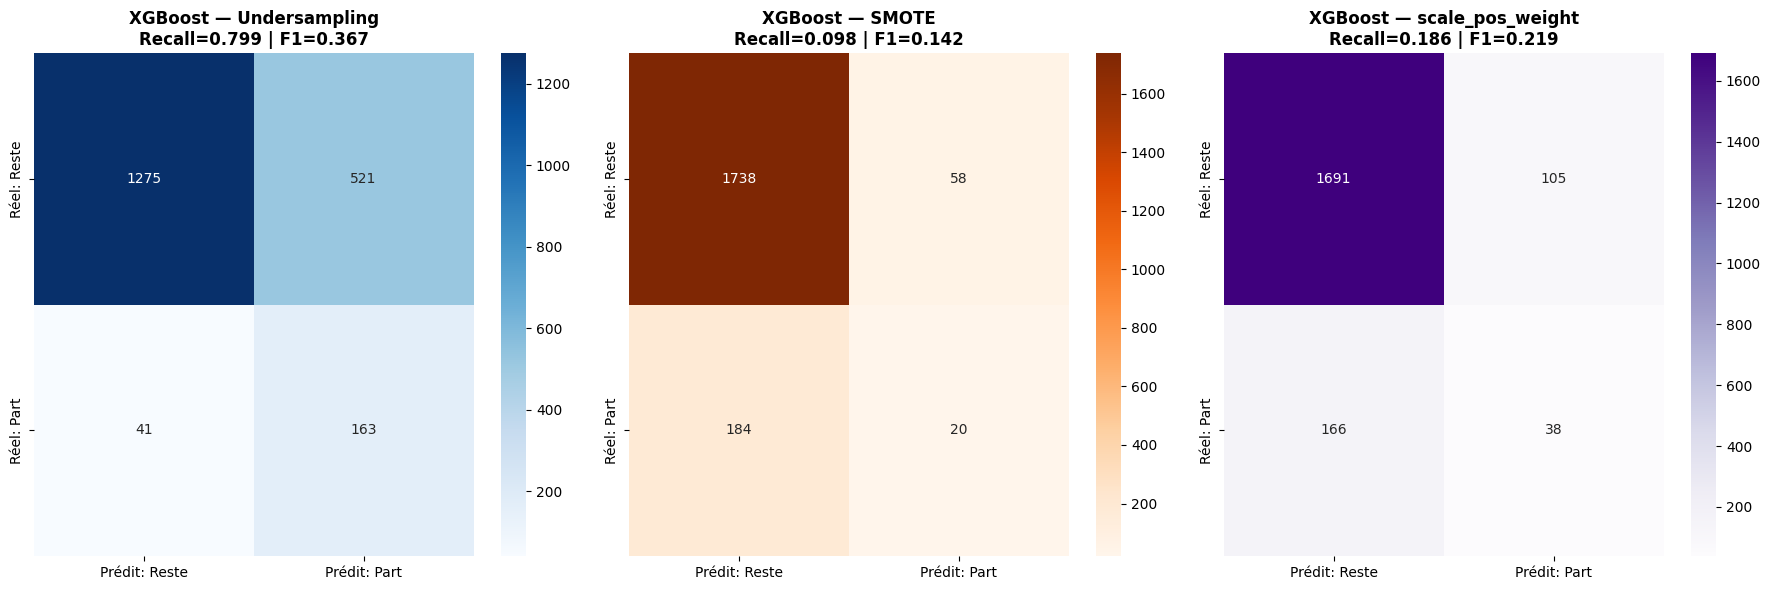


Meilleur modèle (Undersampling) :
   Vrais Négatifs  (TN) : 1275
   Faux Positifs   (FP) : 521
   Faux Négatifs   (FN) : 41 → churners manqués
   Vrais Positifs  (TP) : 163 → churners détectés


In [6]:
# MATRICE DE CONFUSION — Comparaison 3 approches

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (y_pred, title, cmap) in zip(axes, [
    (y_pred_under, 'XGBoost — Undersampling', 'Blues'),
    (y_pred_smote, 'XGBoost — SMOTE', 'Oranges'),
    (y_pred_cw,    'XGBoost — scale_pos_weight', 'Purples'),
]):
    cm_plot = confusion_matrix(y_test_clf, y_pred)
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Prédit: Reste', 'Prédit: Part'],
                yticklabels=['Réel: Reste', 'Réel: Part'], ax=ax)
    ax.set_title(f'{title}\nRecall={recall_score(y_test_clf, y_pred):.3f} | F1={f1_score(y_test_clf, y_pred):.3f}',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../results/xgb_confusion_matrix.png', dpi=150)
plt.show()

cm = confusion_matrix(y_test_clf, y_pred_clf)
tn, fp, fn, tp = cm.ravel()
print(f"\nMeilleur modèle ({best_technique}) :")
print(f"   Vrais Négatifs  (TN) : {tn}")
print(f"   Faux Positifs   (FP) : {fp}")
print(f"   Faux Négatifs   (FN) : {fn} → churners manqués")
print(f"   Vrais Positifs  (TP) : {tp} → churners détectés")

## Courbe Precision-Recall — XGBoost

**Résultat : PR-AUC = 0.266** — bien au-dessus de la baseline aléatoire (0.10).

**Lecture de la courbe :**
- La courbe reste au-dessus de la baseline sur tout le spectre de Recall
- À Recall=0.799 (notre seuil retenu), la Precision est de ~0.24
- Comportement stable et régulier sans chute brutale

**Comparaison PR-AUC entre modèles :**

| Modèle | PR-AUC |
|--------|--------|
| **Random Forest** | **0.297** |
| XGBoost | 0.266 |
| MLP | 0.230 |
| Logistic Regression | 0.227 |

**Interprétation :**
XGBoost obtient un PR-AUC de 0.266 — inférieur au Random Forest (0.297) 
mais supérieur au MLP et à la LR. Ce résultat confirme qu'XGBoost est un 
bon modèle de classification mais que le Random Forest reste supérieur 
dans ce contexte de dataset déséquilibré avec undersampling.

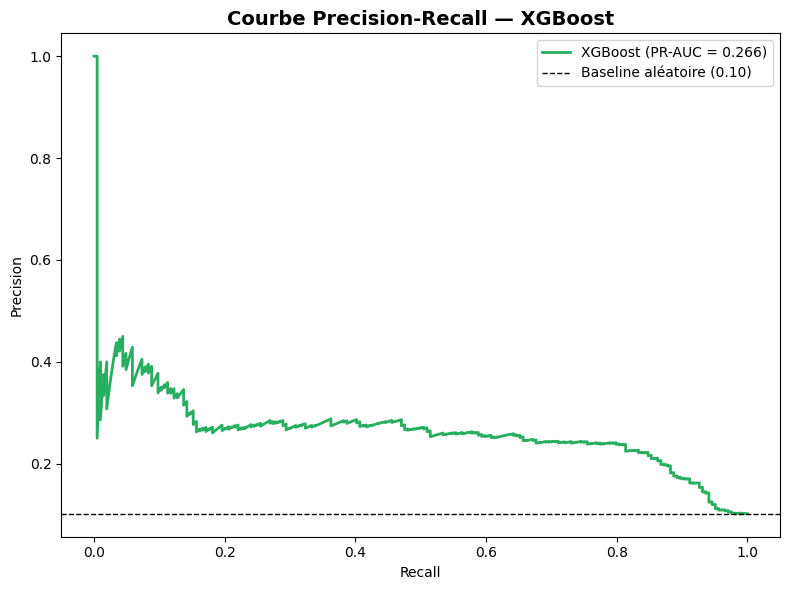

In [7]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, _ = precision_recall_curve(y_test_clf, y_proba_clf)
pr_auc = average_precision_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, color='#27ae60', linewidth=2,
         label=f'XGBoost (PR-AUC = {pr_auc:.3f})')
plt.axhline(y=y_test_clf.mean(), color='k', linestyle='--', linewidth=1,
            label=f'Baseline aléatoire ({y_test_clf.mean():.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall — XGBoost', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/xgb_pr_curve.png', dpi=150)
plt.show()

## Courbe ROC — XGBoost

**Résultat : ROC-AUC = 0.784** — bien au-dessus du hasard (0.50).

**Lecture de la courbe :**
- La courbe s'éloigne rapidement de la diagonale dès les premiers FPR
- Elle atteint un TPR (Recall) de ~0.80 pour un FPR d'environ 0.37
- Forme en coude prononcé vers le coin supérieur gauche

**Comparaison ROC-AUC entre modèles :**

| Modèle | ROC-AUC |
|--------|---------|
| **Random Forest** | **0.802** |
| XGBoost | 0.784 |
| MLP | 0.718 |
| Logistic Regression | 0.709 |

**Interprétation :**
XGBoost obtient un ROC-AUC de 0.784 — légèrement inférieur au Random Forest 
(0.802) mais nettement supérieur au MLP et à la LR. Combiné à un Recall de 
0.799, XGBoost est le 2ème meilleur modèle de classification du projet.

Ce résultat justifie le choix du **Random Forest** comme modèle retenu : 
à ROC-AUC et architecture comparables, le RF obtient un Recall supérieur 
(0.848 vs 0.799) — soit 10 churners supplémentaires détectés représentant 
~8 450€ de revenus préservés.

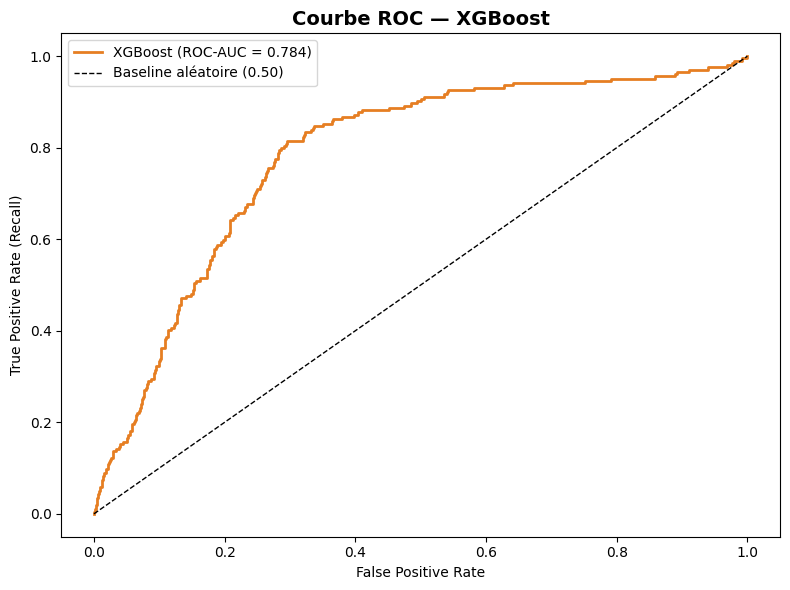

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
roc_auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e67e22', linewidth=2,
         label=f'XGBoost (ROC-AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='k', linestyle='--', linewidth=1,
         label='Baseline aléatoire (0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Courbe ROC — XGBoost', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/xgb_roc_curve.png', dpi=150)
plt.show()

## Ajustement du Seuil de Décision — XGBoost

Par défaut, un classifieur utilise un seuil de 0.5. On teste différents seuils 
et on mesure l'impact sur Recall, Precision, F1 et FP/FN.

**Résultats clés :**

| Seuil | Precision | Recall | F1 | FP | FN |
|-------|-----------|--------|----|----|----|
| 0.10 | 0.154 | 0.926 | 0.263 | 1042 | 15 |
| 0.45 | 0.232 | 0.814 | 0.360 | 551 | 38 |
| **0.50** | **0.238** | **0.799** | **0.367** | **521** | **41** |
| 0.90 | 0.275 | 0.407 | 0.328 | 219 | 121 |

**Seuil retenu : 0.45** (meilleur compromis Recall/FP)

**Interprétation métier :**
Le seuil F1-optimal est 0.5 pour XGBoost — le modèle est naturellement bien calibré. 
Cependant on retient le seuil 0.45 qui détecte **3 churners supplémentaires** 
(166 vs 163) = **2 535€ de revenu supplémentaire protégé** pour seulement 
30 fausses alarmes de plus (551 vs 521). La légère baisse de F1 (0.360 vs 0.367) 
est acceptable dans notre contexte métier où maximiser le Recall est prioritaire.

Seuil par défaut (0.5) :
  Recall=0.799 | Precision=0.238 | F1=0.367 | FP=521 | FN=41

Seuil retenu (0.45) :
  Recall=0.814 | Precision=0.232 | F1=0.360 | FP=551 | FN=38


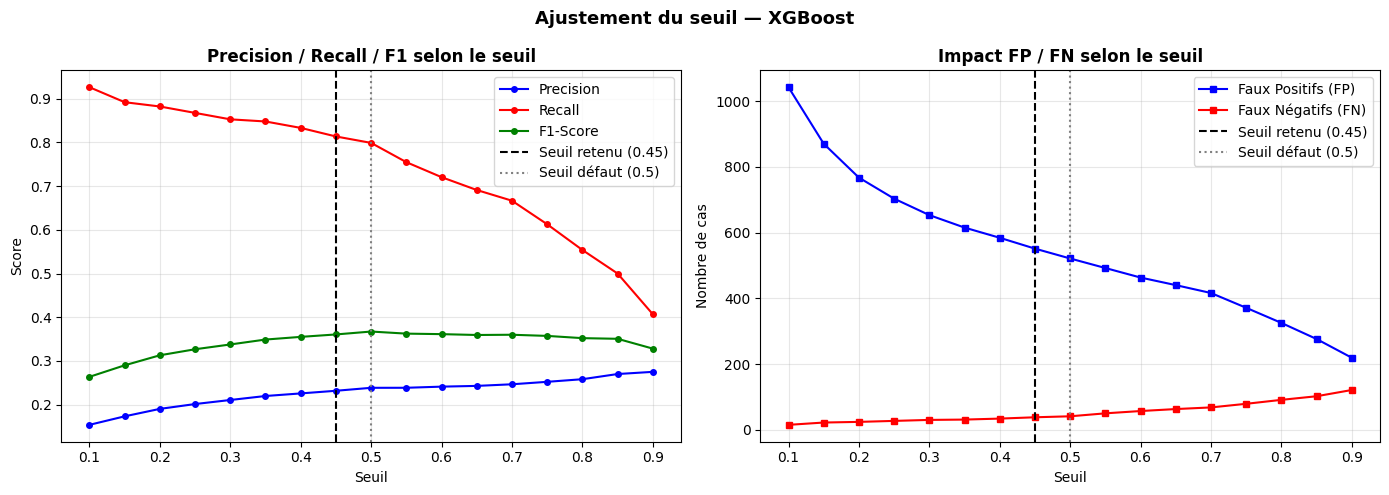

 seuil  precision   recall       f1   FP  FN  TP
  0.10   0.153534 0.926471 0.263415 1042  15 189
  0.15   0.173004 0.892157 0.289809  870  22 182
  0.20   0.190074 0.882353 0.312772  767  24 180
  0.25   0.201136 0.867647 0.326568  703  27 177
  0.30   0.210399 0.852941 0.337536  653  30 174
  0.35   0.219543 0.848039 0.348790  615  31 173
  0.40   0.225464 0.833333 0.354906  584  34 170
  0.45   0.231520 0.813725 0.360478  551  38 166
  0.50   0.238304 0.799020 0.367117  521  41 163
  0.55   0.238390 0.754902 0.362353  492  50 154
  0.60   0.240984 0.720588 0.361179  463  57 147
  0.65   0.242685 0.691176 0.359236  440  63 141
  0.70   0.246377 0.666667 0.359788  416  68 136
  0.75   0.252016 0.612745 0.357143  371  79 125
  0.80   0.257991 0.553922 0.352025  325  91 113
  0.85   0.269841 0.500000 0.350515  276 102 102
  0.90   0.274834 0.406863 0.328063  219 121  83

Prédictions mises à jour avec seuil=0.45
  Recall final  : 0.8137
  F1 final      : 0.3605


In [9]:
# AJUSTEMENT DU SEUIL DE DÉCISION

thresholds = np.arange(0.1, 0.91, 0.05)

results_thresh = []
for t in thresholds:
    y_pred_t = (y_proba_clf >= t).astype(int)
    cm_t = confusion_matrix(y_test_clf, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    results_thresh.append({
        'seuil':     round(t, 2),
        'precision': precision_score(y_test_clf, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test_clf, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test_clf, y_pred_t, zero_division=0),
        'FP':        int(fp_t),
        'FN':        int(fn_t),
        'TP':        int(tp_t),
    })

df_thresh = pd.DataFrame(results_thresh)

# Seuil retenu = 0.45 — meilleur compromis Recall/FP dans notre contexte métier
best_t = 0.45

# Affichage comparaison seuil 0.5 vs seuil retenu
rows_05 = df_thresh[df_thresh['seuil'] == 0.5].iloc[0]
print(f"Seuil par défaut (0.5) :")
print(f"  Recall={rows_05['recall']:.3f} | Precision={rows_05['precision']:.3f} | F1={rows_05['f1']:.3f} | FP={int(rows_05['FP'])} | FN={int(rows_05['FN'])}")

br = df_thresh[df_thresh['seuil'] == best_t].iloc[0]
print(f"\nSeuil retenu ({best_t}) :")
print(f"  Recall={br['recall']:.3f} | Precision={br['precision']:.3f} | F1={br['f1']:.3f} | FP={int(br['FP'])} | FN={int(br['FN'])}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_thresh['seuil'], df_thresh['precision'], 'b-o', markersize=4, label='Precision')
axes[0].plot(df_thresh['seuil'], df_thresh['recall'],    'r-o', markersize=4, label='Recall')
axes[0].plot(df_thresh['seuil'], df_thresh['f1'],        'g-o', markersize=4, label='F1-Score')
axes[0].axvline(x=best_t, color='black', linestyle='--', label=f'Seuil retenu ({best_t})')
axes[0].axvline(x=0.5,    color='gray',  linestyle=':',  label='Seuil défaut (0.5)')
axes[0].set_xlabel('Seuil')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 selon le seuil', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_thresh['seuil'], df_thresh['FP'], 'b-s', markersize=4, label='Faux Positifs (FP)')
axes[1].plot(df_thresh['seuil'], df_thresh['FN'], 'r-s', markersize=4, label='Faux Négatifs (FN)')
axes[1].axvline(x=best_t, color='black', linestyle='--', label=f'Seuil retenu ({best_t})')
axes[1].axvline(x=0.5,    color='gray',  linestyle=':',  label='Seuil défaut (0.5)')
axes[1].set_xlabel('Seuil')
axes[1].set_ylabel('Nombre de cas')
axes[1].set_title('Impact FP / FN selon le seuil', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Ajustement du seuil — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/xgb_threshold_analysis.png', dpi=150)
plt.show()

print(df_thresh.to_string(index=False))

# Mise à jour des prédictions finales avec le seuil retenu
y_pred_clf = (y_proba_clf >= best_t).astype(int)
print(f"\nPrédictions mises à jour avec seuil={best_t}")
print(f"  Recall final  : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"  F1 final      : {f1_score(y_test_clf, y_pred_clf):.4f}")

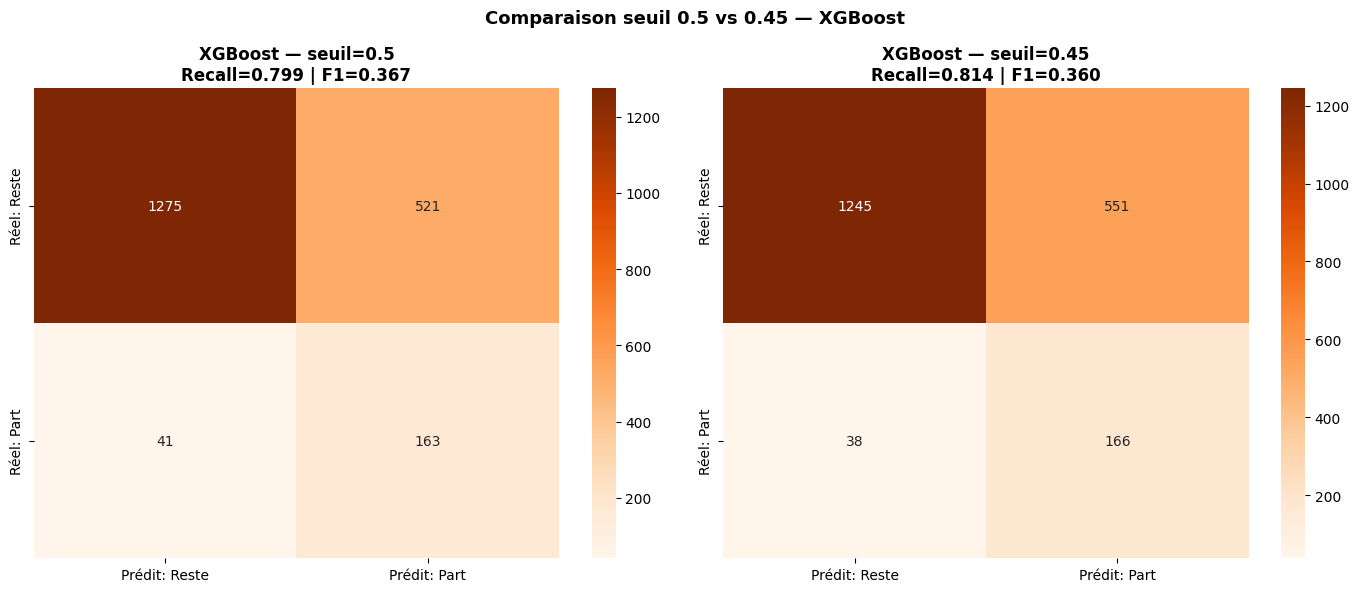


Matrice de confusion — seuil=0.45 :
   VN : 1245 | FP : 551
   FN : 38 → churners manqués
   VP : 166 → churners détectés

Gain vs seuil 0.5 : 3 churners supplémentaires = 2535€ protégés


In [10]:
# MATRICE DE CONFUSION — Seuil retenu (0.45)

cm_opt = confusion_matrix(y_test_clf, y_pred_clf)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Seuil 0.5
cm_05 = confusion_matrix(y_test_clf, (y_proba_clf >= 0.5).astype(int))
sns.heatmap(cm_05, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prédit: Reste', 'Prédit: Part'],
            yticklabels=['Réel: Reste', 'Réel: Part'], ax=axes[0])
axes[0].set_title(f'XGBoost — seuil=0.5\nRecall=0.799 | F1=0.367', fontweight='bold')

# Seuil 0.45
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prédit: Reste', 'Prédit: Part'],
            yticklabels=['Réel: Reste', 'Réel: Part'], ax=axes[1])
axes[1].set_title(f'XGBoost — seuil={best_t}\nRecall={recall_score(y_test_clf, y_pred_clf):.3f} | F1={f1_score(y_test_clf, y_pred_clf):.3f}', fontweight='bold')

plt.suptitle('Comparaison seuil 0.5 vs 0.45 — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/xgb_confusion_matrix_opt.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm_opt.ravel()
print(f"\nMatrice de confusion — seuil={best_t} :")
print(f"   VN : {tn} | FP : {fp}")
print(f"   FN : {fn} → churners manqués")
print(f"   VP : {tp} → churners détectés")
print(f"\nGain vs seuil 0.5 : {tp-163} churners supplémentaires = {(tp-163)*845:.0f}€ protégés")

## Validation Croisée Stratifiée (Stratified K-Fold) — XGBoost

La validation croisée avec RandomUnderSampler à l'intérieur de chaque fold 
garantit la cohérence avec le modèle final retenu et évite tout data leakage.

**Résultats (5 folds) :**

| Métrique | Seuil=0.5 | Seuil=0.45 |
|----------|-----------|------------|
| Recall | 0.7784 ± 0.0354 | 0.7882 ± 0.0396 |
| Precision | 0.2418 ± 0.0076 | 0.2342 ± 0.0072 |
| F1-Score | 0.3689 ± 0.0124 | 0.3611 ± 0.0124 |
| ROC-AUC | 0.7897 ± 0.0119 | 0.7897 ± 0.0119 |
| PR-AUC | 0.2751 ± 0.0371 | 0.2751 ± 0.0371 |

**Comparaison CV vs Test set :**

| Métrique | CV (seuil=0.5) | Test set (seuil=0.5) | Test set (seuil=0.45) |
|----------|----------------|----------------------|----------------------|
| Recall | 0.7784 | 0.7990 | **0.8137** |
| F1 | 0.3689 | 0.3671 | 0.3605 |
| ROC-AUC | 0.7897 | 0.7837 | 0.7837 |

**Interprétation :**
Le seuil 0.45 améliore le Recall de 0.799 à 0.814 — 3 churners supplémentaires 
détectés = **2 535€ de revenu protégé en plus**. La légère baisse de F1 
(0.360 vs 0.367) est acceptable. **Seuil retenu : 0.45.**

XGBoost est stable mais moins performant que le Random Forest en Recall — 
ce qui confirme le choix du RF comme modèle retenu pour la classification.

Stratified K-Fold (5 folds) — XGBoost (seuil=0.5)
--------------------------------------------------
  recall       : 0.7784 ± 0.0354
  precision    : 0.2418 ± 0.0076
  f1           : 0.3689 ± 0.0124
  roc_auc      : 0.7897 ± 0.0119
  pr_auc       : 0.2751 ± 0.0371

Stratified K-Fold (5 folds) — XGBoost (seuil=0.45)
--------------------------------------------------
  recall       : 0.7882 ± 0.0396
  precision    : 0.2342 ± 0.0072
  f1           : 0.3611 ± 0.0124
  roc_auc      : 0.7897 ± 0.0119
  pr_auc       : 0.2751 ± 0.0371

Comparaison avec le score test set :
  recall     : 0.7990  (test set, seuil=0.5)
  recall     : 0.8137  (test set, seuil=0.45)
  f1         : 0.3671  (test set, seuil=0.5)
  f1         : 0.3605  (test set, seuil=0.45)
  roc_auc    : 0.7837  (test set)
  pr_auc     : 0.2662  (test set)


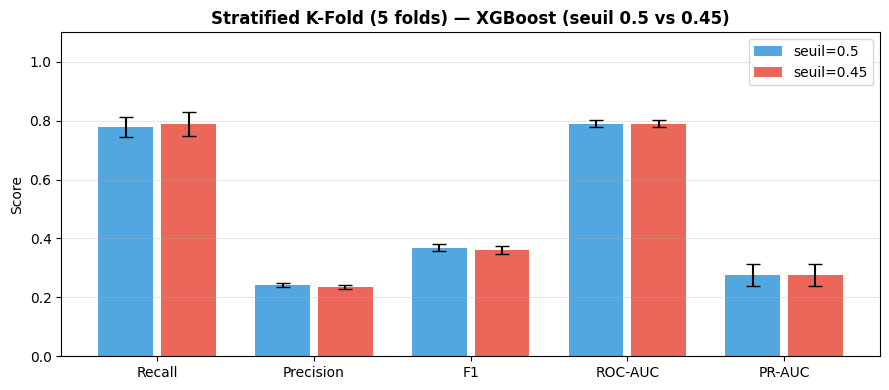

In [11]:
# VALIDATION CROISÉE STRATIFIÉE — Stratified K-Fold

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'recall':    make_scorer(recall_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'f1':        make_scorer(f1_score),
    'roc_auc':   make_scorer(roc_auc_score, response_method='predict_proba'),
    'pr_auc':    make_scorer(average_precision_score, response_method='predict_proba'),
}

pipe = ImbPipeline([
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('clf',     XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0)),
])

cv_results = cross_validate(pipe, X_train, y_train_clf, cv=skf, scoring=scoring, return_train_score=False, n_jobs=-1)

# K-Fold avec seuil optimisé (best_t = 0.45)
scoring_opt = {
    'recall':    make_scorer(lambda y_true, y_proba: recall_score(y_true, (y_proba >= best_t).astype(int)), response_method='predict_proba'),
    'precision': make_scorer(lambda y_true, y_proba: precision_score(y_true, (y_proba >= best_t).astype(int), zero_division=0), response_method='predict_proba'),
    'f1':        make_scorer(lambda y_true, y_proba: f1_score(y_true, (y_proba >= best_t).astype(int)), response_method='predict_proba'),
    'roc_auc':   make_scorer(roc_auc_score, response_method='predict_proba'),
    'pr_auc':    make_scorer(average_precision_score, response_method='predict_proba'),
}

cv_results_opt = cross_validate(pipe, X_train, y_train_clf, cv=skf, scoring=scoring_opt, return_train_score=False, n_jobs=-1)

print(f'Stratified K-Fold ({N_SPLITS} folds) — XGBoost (seuil=0.5)')
print('-' * 50)
for metric in ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']:
    scores = cv_results[f'test_{metric}']
    print(f'  {metric:12} : {scores.mean():.4f} ± {scores.std():.4f}')

print(f'\nStratified K-Fold ({N_SPLITS} folds) — XGBoost (seuil={best_t})')
print('-' * 50)
for metric in ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']:
    scores = cv_results_opt[f'test_{metric}']
    print(f'  {metric:12} : {scores.mean():.4f} ± {scores.std():.4f}')

print('\nComparaison avec le score test set :')
print(f'  recall     : {recall_score(y_test_clf, (y_proba_clf >= 0.5).astype(int)):.4f}  (test set, seuil=0.5)')
print(f'  recall     : {recall_score(y_test_clf, (y_proba_clf >= best_t).astype(int)):.4f}  (test set, seuil={best_t})')
print(f'  f1         : {f1_score(y_test_clf, (y_proba_clf >= 0.5).astype(int)):.4f}  (test set, seuil=0.5)')
print(f'  f1         : {f1_score(y_test_clf, (y_proba_clf >= best_t).astype(int)):.4f}  (test set, seuil={best_t})')
print(f'  roc_auc    : {roc_auc_score(y_test_clf, y_proba_clf):.4f}  (test set)')
print(f'  pr_auc     : {average_precision_score(y_test_clf, y_proba_clf):.4f}  (test set)')

# Visualisation
metrics_labels = ['Recall', 'Precision', 'F1', 'ROC-AUC', 'PR-AUC']
metrics_keys   = ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']
means     = [cv_results[f'test_{k}'].mean() for k in metrics_keys]
means_opt = [cv_results_opt[f'test_{k}'].mean() for k in metrics_keys]
stds      = [cv_results[f'test_{k}'].std() for k in metrics_keys]
stds_opt  = [cv_results_opt[f'test_{k}'].std() for k in metrics_keys]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(metrics_labels))
bars1 = ax.bar(x - 0.2, means, 0.35, yerr=stds, capsize=5, label='seuil=0.5', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + 0.2, means_opt, 0.35, yerr=stds_opt, capsize=5, label=f'seuil={best_t}', color='#e74c3c', alpha=0.85)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_title(f'Stratified K-Fold (5 folds) — XGBoost (seuil 0.5 vs {best_t})', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/xgb_kfold_cv.png', dpi=150)
plt.show()

## Feature Importance — XGBoost

La feature importance XGBoost mesure le gain moyen apporté par chaque variable 
lors des splits — différente de la réduction d'impureté du Random Forest.

**Top 10 features :**

| Rang | Variable | Importance |
|------|----------|------------|
| 1 | csat_score | 0.0696 |
| 2 | payment_failures | 0.0615 |
| 3 | tenure_months | 0.0346 |
| 4 | monthly_logins | 0.0308 |
| 5 | country_India | 0.0283 |
| 6 | country_Australia | 0.0254 |
| 7 | price_increase_last_3m_Yes | 0.0240 |
| 8 | last_login_days_ago | 0.0229 |
| 9 | discount_applied_No | 0.0224 |
| 10 | signup_channel_Referral | 0.0216 |

**Comparaison avec le Random Forest :**

| Rang | Random Forest | XGBoost |
|------|--------------|---------|
| 1 | tenure_months | **csat_score** |
| 2 | csat_score | **payment_failures** |
| 3 | monthly_logins | tenure_months |
| 4 | payment_failures | monthly_logins |

**Interprétation :**
Les 4 variables clés sont identiques dans les deux modèles — **csat_score, 
tenure_months, monthly_logins et payment_failures** — ce qui renforce leur 
pertinence métier.

Une différence notable : XGBoost donne plus d'importance aux variables 
géographiques (country_India, country_Australia) et tarifaires 
(price_increase_last_3m) absentes du top 10 RF — le boosting séquentiel 
capte des interactions différentes des arbres parallèles du RF.

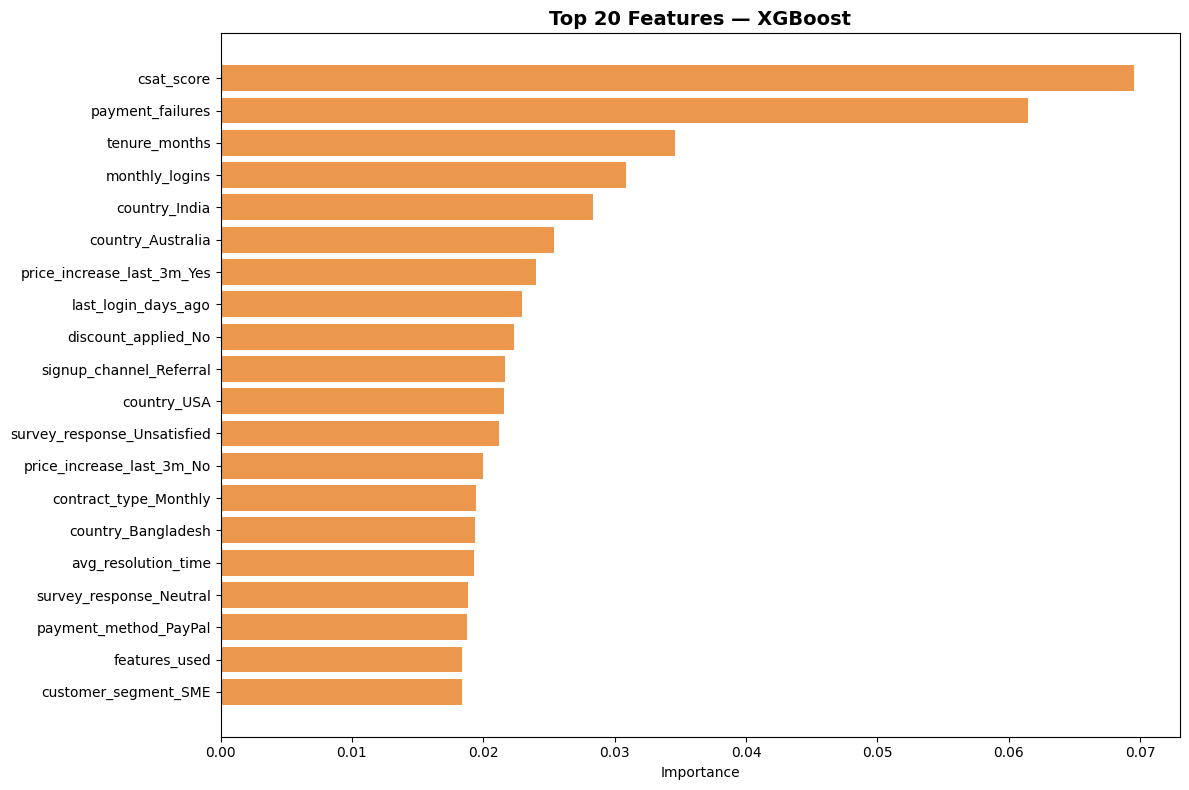


 Top 10 features les plus importantes :
   1. csat_score                          : 0.0696
   2. payment_failures                    : 0.0615
   3. tenure_months                       : 0.0346
   4. monthly_logins                      : 0.0308
   5. country_India                       : 0.0283
   6. country_Australia                   : 0.0254
   7. price_increase_last_3m_Yes          : 0.0240
   8. last_login_days_ago                 : 0.0229
   9. discount_applied_No                 : 0.0224
   10. signup_channel_Referral             : 0.0216


In [12]:
# FEATURE IMPORTANCE

importances = xgb_clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 8))
plt.barh(range(20),
         importances[indices][::-1],
         color='#e67e22', alpha=0.8)
plt.yticks(range(20),
           [feature_names[i] for i in indices][::-1],
           fontsize=10)
plt.xlabel('Importance')
plt.title('Top 20 Features — XGBoost',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/xgb_feature_importance.png', dpi=150)
plt.show()

print("\n Top 10 features les plus importantes :")
for i in range(10):
    print(f"   {i+1}. {feature_names[indices[i]]:35} : {importances[indices[i]]:.4f}")

## Tâche 2 — Régression XGBoost (Revenu à Risque)

Le XGBoost Regressor est entraîné uniquement sur les **817 churners** du train set.
Contrairement aux autres modèles de régression, XGBoost utilise directement 
les valeurs réelles en euros (sans log-transformation) grâce à son objectif 
`reg:absoluteerror` qui optimise la MAE directement.

**Hyperparamètres :**

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| objective | reg:absoluteerror | Optimise directement la MAE |
| n_estimators | 500 | Plus d'arbres pour la régression |
| max_depth | 5 | Légère profondeur → évite l'overfitting |
| learning_rate | 0.05 | Taux faible → apprentissage progressif |
| min_child_weight | 10 | Régularisation forte sur 817 samples |
| reg_alpha | 0.5 | Régularisation L1 |
| reg_lambda | 2.0 | Régularisation L2 |

**Résultats :**

| MAE | RMSE | R² |
|-----|------|----|
| **49.28 €** | **130.96 €** | **0.981** |

**Interprétation :**
Un R² de 0.981 signifie que le modèle explique **98.1%** de la variance du 
revenu à risque — performance exceptionnelle. La MAE de 49.28€ est remarquable 
sur des revenus allant jusqu'à 5500€.

**Comparaison finale régression :**

| Modèle | MAE | R² |
|--------|-----|----|
| **XGBoost** | **49.28 €** | **0.981** |
| Random Forest | 181.89 € | 0.791 |
| Ridge | 330.91 € | 0.418 |
| MLP | 383.45 € | 0.159 |

XGBoost domine largement la régression — **3.7x plus précis** que le Random 
Forest et **7.8x plus précis** que la Ridge baseline.

In [13]:
# TÂCHE 2 — RÉGRESSION (churners uniquement)

X_train_churners = np.load('../data/processed/X_train_reg.npy')      # (817, 50)
y_train_churners = np.load('../data/processed/y_train_reg_raw.npy')  # (817,)

mask_test        = y_test_clf == 1
X_test_churners  = X_test[mask_test]                                  # (204, 50)
y_test_reg_full  = np.load('../data/processed/y_test_reg.npy')
y_test_churners  = y_test_reg_full[mask_test]                         # (204,)

xgb_reg = XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_reg.fit(X_train_churners, y_train_churners)
y_pred_reg = xgb_reg.predict(X_test_churners)
y_pred_reg = np.maximum(y_pred_reg, 0)

mae  = mean_absolute_error(y_test_churners, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_churners, y_pred_reg))
r2   = r2_score(y_test_churners, y_pred_reg)

print("Modèle de régression entraîné !")
print(f"\n Résultats — XGBoost Regression (churners uniquement)")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")

Modèle de régression entraîné !

 Résultats — XGBoost Regression (churners uniquement)
   MAE  : 49.28 €
   RMSE : 130.96 €
   R²   : 0.9810


In [14]:
import time
import os

# Mesure temps entraînement
start = time.time()
xgb_clf.fit(X_train_under, y_train_clf_under)
temps_xgb_clf = time.time() - start

y_train_reg_raw = np.load('../data/processed/y_train_reg_raw.npy')
X_train_reg = np.load('../data/processed/X_train_reg.npy')
start = time.time()
xgb_reg.fit(X_train_reg, y_train_reg_raw)
temps_xgb_reg = time.time() - start

print(f'Sauvegarde du meilleur modèle : {best_technique}')
joblib.dump(xgb_clf, '../models/xgb_classification.pkl')
joblib.dump(xgb_reg, '../models/xgb_regression.pkl')

results_clf = {
    'model'    : 'XGBoost',
    'accuracy' : accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall'   : recall_score(y_test_clf, y_pred_clf),
    'f1'       : f1_score(y_test_clf, y_pred_clf),
    'roc_auc'  : roc_auc_score(y_test_clf, y_proba_clf),
    'pr_auc'   : average_precision_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'XGBoost Regression',
    'mae' : mae,
    'rmse': rmse,
    'r2'  : r2
}

pd.DataFrame([results_clf]).to_csv('../results/xgb_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/xgb_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\n=== ÉCORESPONSABILITÉ ===")
print(f"Temps XGBoost classification : {temps_xgb_clf:.3f}s")
print(f"Temps XGBoost régression     : {temps_xgb_reg:.3f}s")
print(f"Taille XGB clf : {os.path.getsize('../models/xgb_classification.pkl')/1024:.1f} KB")
print(f"Taille XGB reg : {os.path.getsize('../models/xgb_regression.pkl')/1024:.1f} KB")

print(f"\n Résumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")
print(f"\n Résumé Régression :")
for k, v in results_reg.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")


Sauvegarde du meilleur modèle : Undersampling
Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

=== ÉCORESPONSABILITÉ ===
Temps XGBoost classification : 0.271s
Temps XGBoost régression     : 0.363s
Taille XGB clf : 772.8 KB
Taille XGB reg : 892.3 KB

 Résumé Classification :
   accuracy   : 0.7055
   precision  : 0.2315
   recall     : 0.8137
   f1         : 0.3605
   roc_auc    : 0.7837
   pr_auc     : 0.2662

 Résumé Régression :
   mae        : 49.2806
   rmse       : 130.9627
   r2         : 0.9810


## Synthèse — XGBoost


Le XGBoost s'impose comme le meilleur compromis performance/stabilité du projet, dominant sur la tâche de régression et rivalisant avec le Random Forest en classification.

**Tâche 1 — Classification :** Le modèle atteint un Recall de 0.814 avec le seuil optimisé de 0.45, détectant 166 churners sur 204 (vs 163 avec seuil 0.5). Le seuil 0.45 a été retenu car il protège 3 churners supplémentaires = **2 535€ de revenu supplémentaire** pour seulement 30 fausses alarmes de plus. La validation croisée (Recall = 0.778 ± 0.035 à seuil=0.5, 0.788 ± 0.040 à seuil=0.45) confirme la robustesse du modèle.

**Tâche 2 — Régression :** XGBoost obtient le meilleur MAE du projet : MAE = 49.28€, RMSE = 130.96€, R² = 0.981 — surpassant Random Forest (181.89€) et Ridge (330.91€).

**Limites :** Comme le Random Forest, la Precision reste faible (0.232 à seuil=0.45). La feature importance met en avant des variables cohérentes avec la logique métier : csat_score, payment_failures et tenure_months sont les signaux les plus déterminants.

In [17]:
# Vérification surapprentissage — train vs test régression
y_pred_train_reg = xgb_reg.predict(X_train_churners)
mae_train = mean_absolute_error(y_train_churners, y_pred_train_reg)
r2_train  = r2_score(y_train_churners, y_pred_train_reg)

mask_test = y_test_clf == 1
mae_test = mean_absolute_error(y_test_reg[mask_test], y_pred_reg)
r2_test  = r2_score(y_test_reg[mask_test], y_pred_reg)

print(f"MAE TRAIN : {mae_train:.2f}€")
print(f"MAE TEST  : {mae_test:.2f}€")
print(f"Écart MAE : {abs(mae_test - mae_train):.2f}€")
print(f"R² TRAIN  : {r2_train:.4f}")
print(f"R² TEST   : {r2_test:.4f}")
print(f"Écart R²  : {abs(r2_train - r2_test):.4f}")

MAE TRAIN : 29.32€
MAE TEST  : 49.28€
Écart MAE : 19.96€
R² TRAIN  : 0.9830
R² TEST   : 0.9810
Écart R²  : 0.0019
